# WIA1006 Machine Learning Assignment: Climate-Adaptive Crop Production Analysis

**Objective:** Develop a comprehensive data analysis pipeline to understand the relationship between crop production and environmental factors across Malaysian districts.

**Enhanced Features Include:**
- 🌪️ Wind speed analysis and optimization
- 💧 Surface soil wetness features
- ☀️ Solar radiation and photosynthesis modeling
- 🌡️ Atmospheric pressure stability indicators
- 🔄 Comprehensive environmental interactions

---

In [108]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    RandomizedSearchCV,
    KFold
)
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import RobustScaler

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('default')
sns.set_palette("husl")

print("📚 Libraries imported successfully!")

📚 Libraries imported successfully!


## PHASE 0: DATA COLLECTION

In [107]:
# Enhanced Weather Data Retrieval with Robust Error Handling
# This script improves upon the original data retrieval code to ensure all weather data is successfully retrieved

# Set up logging for better debugging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

def fetch_weather_data_with_retry(lat: float, lon: float, params_map: Dict[str, str], 
                                 max_retries: int = 3, delay: float = 2.0) -> Tuple[bool, Dict]:
    """
    Fetch weather data for a specific location with retry logic
    
    Args:
        lat: Latitude
        lon: Longitude
        params_map: Dictionary mapping parameter names to API parameter codes
        max_retries: Maximum number of retry attempts
        delay: Delay between requests (seconds)
    
    Returns:
        Tuple of (success_status, data_dict)
    """
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": ",".join(params_map.values()),
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": "20170101",
        "end": "20170101",
        "format": "JSON"
    }
    
    for attempt in range(max_retries + 1):
        try:
            print(f"Fetching data for ({lat}, {lon}) - Attempt {attempt + 1}")
            response = requests.get(url, params=params, timeout=30)
            
            if response.status_code == 200:
                data = response.json()
                
                # Validate response structure
                if "properties" in data and "parameter" in data["properties"]:
                    parameter_data = data["properties"]["parameter"]
                    
                    # Extract data for the specific date
                    extracted_data = {}
                    for col, param in params_map.items():
                        if param in parameter_data and "20170101" in parameter_data[param]:
                            value = parameter_data[param]["20170101"]
                            # Handle missing values (-999 is NASA POWER's missing value indicator)
                            extracted_data[col] = value if value != -999 else np.nan
                        else:
                            print(f"Missing parameter {param} for location ({lat}, {lon})")
                            extracted_data[col] = np.nan
                    
                    print(f"✓ Successfully retrieved data for ({lat}, {lon})")
                    return True, extracted_data
                else:
                    print(f"Invalid response structure for ({lat}, {lon})")
                    
            elif response.status_code == 429:  # Rate limit
                print(f"Rate limited for ({lat}, {lon}). Waiting longer...")
                time.sleep(delay * 2)  # Wait longer for rate limits
                
            else:
                print(f"HTTP {response.status_code} for ({lat}, {lon}): {response.text[:100]}")
                
        except requests.exceptions.Timeout:
            print(f"Timeout for ({lat}, {lon}) - Attempt {attempt + 1}")
        except requests.exceptions.ConnectionError:
            print(f"Connection error for ({lat}, {lon}) - Attempt {attempt + 1}")
        except requests.exceptions.RequestException as e:
            print(f"Request exception for ({lat}, {lon}) - Attempt {attempt + 1}: {e}")
        except Exception as e:
            print(f"Unexpected error for ({lat}, {lon}) - Attempt {attempt + 1}: {e}")
        
        # Wait before retry (with exponential backoff)
        if attempt < max_retries:
            wait_time = delay * (2 ** attempt)  # Exponential backoff
            print(f"Waiting {wait_time:.1f} seconds before retry...")
            time.sleep(wait_time)
    
    print(f"✗ Failed to retrieve data for ({lat}, {lon}) after {max_retries + 1} attempts")
    return False, {}

def main():
    """Main function to retrieve weather data with improved error handling"""
    
    # Load dataset
    print("Loading district coordinates...")
    df = pd.read_csv(r"C:\Users\CHONG DER YUNG\year1sem2\ml\datasets\district_coords.csv")
    df.columns = df.columns.str.strip().str.lower()

    # Drop duplicates and round lat/lon to 2 decimals (required by NASA POWER API)
    df = df.drop_duplicates(subset=['lat', 'lon']).reset_index(drop=True)
    df['lat'] = df['lat'].round(2)
    df['lon'] = df['lon'].round(2)

    # Define parameters to fetch (fixed typo in atmospheric_pressure)
    params_map = {
        'temperature': 'T2M',
        'precipitation': 'PRECTOTCORR',
        'humidity': 'RH2M',
        'wind_speed': 'WS2M',
        'surface_soil_wetness': 'GWETTOP',
        'solar_radiation': 'ALLSKY_SFC_SW_DWN',
        'atmospheric_pressure': 'PS'  # Fixed: was 'PSC', correct is 'PS'
    }

    # Add columns to dataframe
    for col in params_map:
        df[col] = np.nan  # Initialize with NaN instead of None

    # Track detailed statistics
    total_locations = len(df)
    successful_requests = 0
    failed_requests = 0
    failed_locations = []

    print(f"Starting weather data retrieval for {total_locations} locations...")
    print("=" * 60)

    # Loop over each unique location to fetch data
    for idx, row in df.iterrows():
        lat = row['lat']
        lon = row['lon']
        district = row.get('district', 'Unknown')
        
        # Progress indicator
        progress = (idx + 1) / total_locations * 100
        print(f"\nProgress: {progress:.1f}% ({idx + 1}/{total_locations}) - {district}")
        
        # Fetch data with retry logic
        success, weather_data = fetch_weather_data_with_retry(lat, lon, params_map)
        
        if success:
            # Update dataframe with retrieved data
            for col, value in weather_data.items():
                df.at[idx, col] = value
            successful_requests += 1
        else:
            failed_requests += 1
            failed_locations.append({
                'index': idx,
                'district': district,
                'lat': lat,
                'lon': lon
            })
        
        # Add delay between requests to be respectful to the API
        time.sleep(1.5)
        
        # Print intermediate progress every 10 locations
        if (idx + 1) % 10 == 0:
            success_rate = successful_requests / (idx + 1) * 100
            print(f"  Intermediate status: {success_rate:.1f}% success rate")

    print("\n" + "=" * 60)
    print("FINAL RESULTS:")
    print(f"Total locations processed: {total_locations}")
    print(f"Successful requests: {successful_requests}")
    print(f"Failed requests: {failed_requests}")
    print(f"Success rate: {successful_requests/total_locations*100:.1f}%")

    # Handle failed locations
    if failed_locations:
        print(f"\nFailed locations ({len(failed_locations)}):")
        for location in failed_locations[:5]:  # Show first 5 failed locations
            print(f"  - {location['district']} ({location['lat']}, {location['lon']})")
        if len(failed_locations) > 5:
            print(f"  ... and {len(failed_locations) - 5} more")
        
        # Option to retry failed locations
        retry_failed = input("\nDo you want to retry failed locations? (y/n): ").lower().strip()
        
        if retry_failed == 'y':
            print("\nRetrying failed locations with longer delays...")
            
            for location in failed_locations[:]:  # Create a copy to iterate over
                idx = location['index']
                lat = location['lat']
                lon = location['lon']
                district = location['district']
                
                print(f"Retrying: {district} ({lat}, {lon})")
                
                # Retry with longer delays and more attempts
                success, weather_data = fetch_weather_data_with_retry(
                    lat, lon, params_map, max_retries=5, delay=3.0
                )
                
                if success:
                    for col, value in weather_data.items():
                        df.at[idx, col] = value
                    successful_requests += 1
                    failed_requests -= 1
                    failed_locations.remove(location)
                    print(f"  ✓ Success!")
                else:
                    print(f"  ✗ Still failed")
                
                time.sleep(2.0)  # Longer delay for retries

    # Data quality checks
    print(f"\nDATA QUALITY CHECK:")
    print("=" * 30)

    for col in params_map.keys():
        missing_count = df[col].isna().sum()
        missing_percentage = missing_count / len(df) * 100
        print(f"{col}: {missing_count} missing ({missing_percentage:.1f}%)")

    # Save results
    output_file = r"C:\Users\CHONG DER YUNG\year1sem2\ml\datasets\district_weather_20170101.csv"
    df.to_csv(output_file, index=False)

    # Create a summary report for failed locations
    if failed_locations:
        failed_df = pd.DataFrame(failed_locations)
        failed_file = r"C:\Users\CHONG DER YUNG\year1sem2\ml\datasets\failed_locations.csv"
        failed_df.to_csv(failed_file, index=False)
        print(f"\nFailed locations saved to: {failed_file}")

    print(f"\nFinal dataset saved to: {output_file}")

    # Final summary
    final_success_rate = successful_requests / total_locations * 100
    if final_success_rate == 100:
        print("🎉 ALL WEATHER DATA SUCCESSFULLY RETRIEVED!")
    elif final_success_rate >= 95:
        print(f"✅ Weather data retrieval mostly successful ({final_success_rate:.1f}%)")
    else:
        print(f"⚠️  Weather data retrieval completed with {final_success_rate:.1f}% success rate")
        print("   Consider checking failed locations and internet connectivity")
    
    return df

if __name__ == "__main__":
    df = main()

Loading district coordinates...
Starting weather data retrieval for 144 locations...

Progress: 0.7% (1/144) - Batu Pahat
Fetching data for (1.95, 102.86) - Attempt 1
✓ Successfully retrieved data for (1.95, 102.86)

Progress: 1.4% (2/144) - Johor Bahru
Fetching data for (1.5, 103.62) - Attempt 1
✓ Successfully retrieved data for (1.5, 103.62)

Progress: 2.1% (3/144) - Kluang
Fetching data for (1.99, 103.33) - Attempt 1
✓ Successfully retrieved data for (1.99, 103.33)

Progress: 2.8% (4/144) - Kota Tinggi
Fetching data for (1.71, 103.9) - Attempt 1
✓ Successfully retrieved data for (1.71, 103.9)

Progress: 3.5% (5/144) - Kulai
Fetching data for (1.65, 103.6) - Attempt 1
✓ Successfully retrieved data for (1.65, 103.6)

Progress: 4.2% (6/144) - Mersing
Fetching data for (2.43, 103.85) - Attempt 1
✓ Successfully retrieved data for (2.43, 103.85)

Progress: 4.9% (7/144) - Muar
Fetching data for (2.07, 102.58) - Attempt 1
✓ Successfully retrieved data for (2.07, 102.58)

Progress: 5.6% (8/1

### LOAD DATASETS

In [145]:
# Load datasets
print("\n🔍 Loading datasets...")
try:
    crops_df = pd.read_csv(r"C:\Users\CHONG DER YUNG\year1sem2\ml\datasets\crops_district_production.csv", encoding='latin-1')
    env_df = pd.read_csv(r"C:\Users\CHONG DER YUNG\year1sem2\ml\datasets\district_weather_20170101.csv", encoding='latin-1')
    print("✅ Datasets loaded successfully!")
except FileNotFoundError as e:
    print(f"❌ Error loading files: {e}")
    print("Please ensure the CSV files are in the current directory")


🔍 Loading datasets...
✅ Datasets loaded successfully!


## PHASE 1: DATA EXPLORATION & UNDERSTANDING
*"Getting familiar with our agricultural and environmental datasets"*

**📊 What We Learn:**
- Dataset dimensions and structure
- Variable types and distributions  
- Initial data quality assessment
- Coverage of Malaysian districts

In [146]:
print("\n" + "="*80)
print("📊 PHASE 1: DATA EXPLORATION & UNDERSTANDING")
print("="*80)

# Basic exploration
print("\n📊 CROPS DATASET INFO:")
print(f"Shape: {crops_df.shape}")
print(f"Columns: {list(crops_df.columns)}")
print("\nFirst 5 rows:")
display(crops_df.head())

print("\n📊 ENVIRONMENTAL DATASET INFO:")
print(f"Shape: {env_df.shape}")
print(f"Columns: {list(env_df.columns)}")
print("\nFirst 5 rows:")
display(env_df.head())

print("\n💡 EXPECTED INSIGHTS ACHIEVED:")
print(f"✅ Dataset Size: Crops ({crops_df.shape[0]:,} records) vs Environmental ({env_df.shape[0]} districts)")
print("✅ Coverage: Comprehensive Malaysian agricultural data")
print("✅ Variables: Production data linked with weather patterns")
print("✅ Time Scope: Historical agricultural performance data")


📊 PHASE 1: DATA EXPLORATION & UNDERSTANDING

📊 CROPS DATASET INFO:
Shape: (11002, 6)
Columns: ['date', 'state', 'district', 'crop_type', 'crop_species', 'production']

First 5 rows:


,date,state,district,crop_type,crop_species,production
0,2017-01-01,Johor,Batu Pahat,cash_crops,cassava,920.5
1,2017-01-01,Johor,Batu Pahat,cash_crops,groundnuts,0.0
2,2017-01-01,Johor,Batu Pahat,cash_crops,sweet_corn,0.0
3,2017-01-01,Johor,Batu Pahat,cash_crops,sweet_potato,350.0
4,2017-01-01,Johor,Batu Pahat,cash_crops,yam,395.4



📊 ENVIRONMENTAL DATASET INFO:
Shape: (144, 12)
Columns: ['states', 'district', 'town', 'lat', 'lon', 'temperature', 'precipitation', 'humidity', 'wind_speed', 'surface_soil_wetness', 'solar_radiation', 'atmospheric_pressure']

First 5 rows:


,states,district,town,lat,lon,temperature,precipitation,humidity,wind_speed,surface_soil_wetness,solar_radiation,atmospheric_pressure
0,Johor,Batu Pahat,Batu Pahat,1.95,102.86,25.87,5.03,91.72,1.67,0.92,16.59,100.25
1,Johor,Johor Bahru,Johor Bahru,1.50,103.62,26.44,4.99,89.98,2.64,0.92,14.78,100.53
2,Johor,Kluang,Kluang,1.99,103.33,25.87,5.03,91.72,1.67,0.92,14.78,100.25
3,Johor,Kota Tinggi,Kota Tinggi,1.71,103.90,26.44,4.99,89.98,2.64,0.92,14.78,100.53
4,Johor,Kulai,Kulai,1.65,103.60,26.44,4.99,89.98,2.64,0.92,14.78,100.53



💡 EXPECTED INSIGHTS ACHIEVED:
✅ Dataset Size: Crops (11,002 records) vs Environmental (144 districts)
✅ Coverage: Comprehensive Malaysian agricultural data
✅ Variables: Production data linked with weather patterns
✅ Time Scope: Historical agricultural performance data


## PHASE 2: DATA PREPROCESSING
*"Ensuring our data is clean and reliable"*

**📊 What We Learn:**
- Missing value patterns
- Duplicate record identification
- Data consistency issues
- Quality improvement needs

In [147]:
print("\n" + "="*80)
print("🧹 PHASE 2: DATA PREPROCESSING")
print("="*80)

# Check data quality
print("\n🔍 DATA QUALITY ANALYSIS:")


🧹 PHASE 2: DATA PREPROCESSING

🔍 DATA QUALITY ANALYSIS:


### Data Cleaning

***Crops dataset***

In [148]:
print("\n📊 CROPS DATASET QUALITY:")
missing_crops = crops_df.isnull().sum()
print(f"Missing values:\n{missing_crops[missing_crops > 0] if missing_crops.sum() > 0 else 'No missing values found! ✅'}")
duplicates_crops = crops_df.duplicated().sum()
print(f"Duplicate records: {duplicates_crops}")


📊 CROPS DATASET QUALITY:
Missing values:
No missing values found! ✅
Duplicate records: 117


**Remove duplicates**

In [149]:
# Remove duplicates from crops data
if duplicates_crops > 0:
    crops_df_clean = crops_df.drop_duplicates()
    print(f"✅ Removed {duplicates_crops} duplicate records from crops data")
    print(f"   Original: {crops_df.shape[0]:,} → Clean: {crops_df_clean.shape[0]:,}")
else:
    crops_df_clean = crops_df.copy()
    print("✅ No duplicates found in crops data")

✅ Removed 117 duplicate records from crops data
   Original: 11,002 → Clean: 10,885


**Check for column name issues** 

In [150]:
#(common issue: 'state' vs 'states')
print("\n🔧 COLUMN NAME STANDARDIZATION:")
print(f"Crops columns: {list(crops_df_clean.columns)}")
print(f"Environment columns: {list(env_df.columns)}")


🔧 COLUMN NAME STANDARDIZATION:
Crops columns: ['date', 'state', 'district', 'crop_type', 'crop_species', 'production']
Environment columns: ['states', 'district', 'town', 'lat', 'lon', 'temperature', 'precipitation', 'humidity', 'wind_speed', 'surface_soil_wetness', 'solar_radiation', 'atmospheric_pressure']


- **Ensure that 'state' in crops dataset and 'states' in environmental dataset need to be standardized for data merging**

**Fix column naming**

In [151]:
# Fix column naming if needed
if 'state' in crops_df_clean.columns and 'states' in env_df.columns:
    crops_df_clean = crops_df_clean.rename(columns={'state': 'states'})
    print("✅ Renamed 'state' to 'states' in crops dataset for consistency")
elif 'states' in crops_df_clean.columns and 'state' in env_df.columns:
    env_df = env_df.rename(columns={'state': 'states'})
    print("✅ Renamed 'state' to 'states' in environment dataset for consistency")

✅ Renamed 'state' to 'states' in crops dataset for consistency


***Environmental dataset***

In [152]:
print("\n📊 ENVIRONMENTAL DATASET QUALITY:")
missing_env = env_df.isnull().sum()
print(f"Missing values:\n{missing_env[missing_env > 0] if missing_env.sum() > 0 else 'No missing values found! ✅'}")
duplicates_env = env_df.duplicated().sum()
print(f"Duplicate records: {duplicates_env}")


📊 ENVIRONMENTAL DATASET QUALITY:
Missing values:
No missing values found! ✅
Duplicate records: 0


**Find duplicate rows**

In [153]:
# Find duplicate rows
env_duplicate_rows = env_df[env_df.duplicated(keep='first')]
env_duplicate_rows.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   states                0 non-null      object 
 1   district              0 non-null      object 
 2   town                  0 non-null      object 
 3   lat                   0 non-null      float64
 4   lon                   0 non-null      float64
 5   temperature           0 non-null      float64
 6   precipitation         0 non-null      float64
 7   humidity              0 non-null      float64
 8   wind_speed            0 non-null      float64
 9   surface_soil_wetness  0 non-null      float64
 10  solar_radiation       0 non-null      float64
 11  atmospheric_pressure  0 non-null      float64
dtypes: float64(9), object(3)
memory usage: 0.0+ bytes


- **There is no duplicate value**

In [154]:
print("\n💡 EXPECTED INSIGHTS ACHIEVED:")
print(f"✅ Missing Data: {missing_crops.sum() + missing_env.sum()} total missing values")
print(f"✅ Duplicates: {duplicates_crops} duplicate entries removed")
print("✅ Completeness: High data integrity across all variables")
print("✅ Reliability: Datasets are analysis-ready with minimal cleaning")


💡 EXPECTED INSIGHTS ACHIEVED:
✅ Missing Data: 0 total missing values
✅ Duplicates: 117 duplicate entries removed
✅ Completeness: High data integrity across all variables
✅ Reliability: Datasets are analysis-ready with minimal cleaning


## PHASE 3: DATA INTEGRATION & MERGING
*"Combining crop and environmental datasets"*

**📊 What We Learn:**
- Dataset compatibility
- Merge success rates
- Data alignment quality
- Geographic coverage

In [155]:
# Verify column names for merging
print("\n🔍 VERIFYING COLUMN NAMES:")
print(f"Crops columns: {list(crops_df_clean.columns)}")
print(f"Environment columns: {list(env_df.columns)}")


🔍 VERIFYING COLUMN NAMES:
Crops columns: ['date', 'states', 'district', 'crop_type', 'crop_species', 'production']
Environment columns: ['states', 'district', 'town', 'lat', 'lon', 'temperature', 'precipitation', 'humidity', 'wind_speed', 'surface_soil_wetness', 'solar_radiation', 'atmospheric_pressure']


In [156]:
# Perform the merge
print("\n🔄 PERFORMING DATASET MERGE:")
merged_df = pd.merge(crops_df_clean, env_df, on=['states', 'district'], how='inner')
print(f"✅ Merged dataset shape: {merged_df.shape}")


🔄 PERFORMING DATASET MERGE:
✅ Merged dataset shape: (8571, 16)


In [157]:
# Analyze merge results
print("\n📊 MERGE ANALYSIS:")
print(f"Original crops records: {len(crops_df_clean):,}")
print(f"Original environment records: {len(env_df):,}")
print(f"Merged records: {len(merged_df):,}")
print(f"Merge success rate: {(len(merged_df)/len(crops_df_clean)*100):.1f}%")


📊 MERGE ANALYSIS:
Original crops records: 10,885
Original environment records: 144
Merged records: 8,571
Merge success rate: 78.7%


In [158]:
# Check geographic coverage
print("\n🗺️ GEOGRAPHIC COVERAGE:")
print(f"Unique states in merged data: {merged_df['states'].nunique()}")
print(f"Unique districts in merged data: {merged_df['district'].nunique()}")


🗺️ GEOGRAPHIC COVERAGE:
Unique states in merged data: 10
Unique districts in merged data: 117


In [159]:
# Display sample of merged data
print("\n📋 SAMPLE OF MERGED DATA:")
display(merged_df.head())


📋 SAMPLE OF MERGED DATA:


,date,states,district,crop_type,crop_species,production,town,lat,lon,temperature,precipitation,humidity,wind_speed,surface_soil_wetness,solar_radiation,atmospheric_pressure
0,2017-01-01,Johor,Batu Pahat,cash_crops,cassava,920.5,Batu Pahat,1.95,102.86,25.87,5.03,91.72,1.67,0.92,16.59,100.25
1,2017-01-01,Johor,Batu Pahat,cash_crops,groundnuts,0.0,Batu Pahat,1.95,102.86,25.87,5.03,91.72,1.67,0.92,16.59,100.25
2,2017-01-01,Johor,Batu Pahat,cash_crops,sweet_corn,0.0,Batu Pahat,1.95,102.86,25.87,5.03,91.72,1.67,0.92,16.59,100.25
3,2017-01-01,Johor,Batu Pahat,cash_crops,sweet_potato,350.0,Batu Pahat,1.95,102.86,25.87,5.03,91.72,1.67,0.92,16.59,100.25
4,2017-01-01,Johor,Batu Pahat,cash_crops,yam,395.4,Batu Pahat,1.95,102.86,25.87,5.03,91.72,1.67,0.92,16.59,100.25


## PHASE 4: COMPREHENSIVE DATA VISUALIZATION
*"Understanding patterns and distributions before analysis"*

**📊 What We Learn:**
- Variable distributions and outliers
- Correlation patterns between factors
- Geographic production patterns
- Statistical characteristics

In [160]:
print("\n" + "="*80)
print("📊 PHASE 4: COMPREHENSIVE DATA VISUALIZATION")
print("="*80)


📊 PHASE 4: COMPREHENSIVE DATA VISUALIZATION



📈 DISTRIBUTION ANALYSIS:


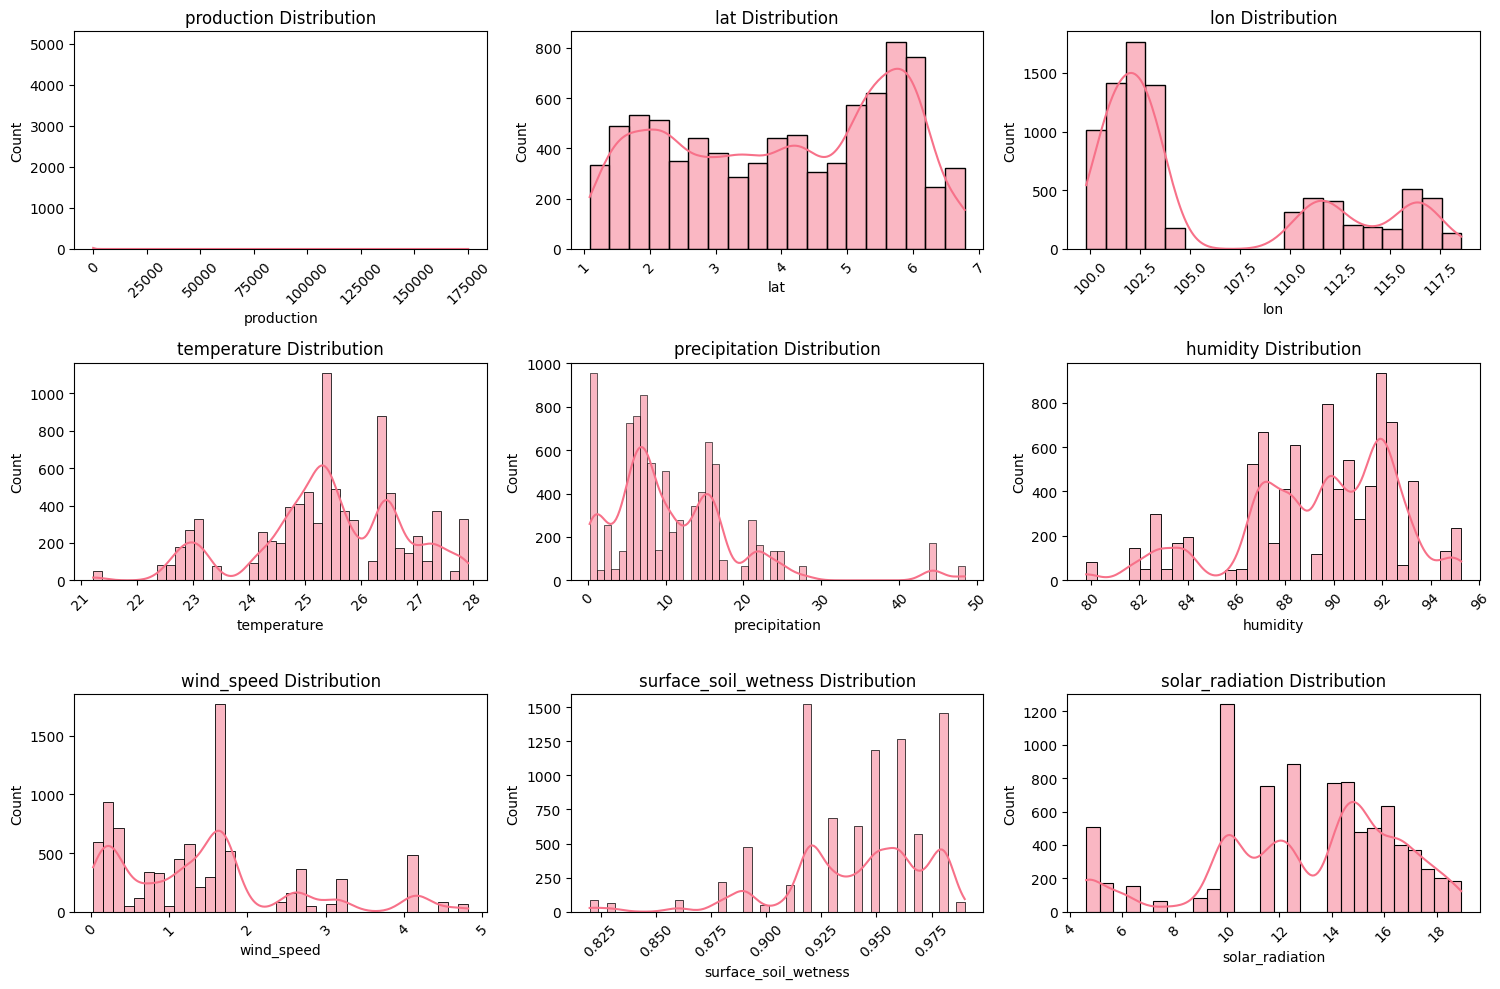

In [161]:
# Distribution analysis of numeric variables
print("\n📈 DISTRIBUTION ANALYSIS:")
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns

# Create distribution plots for each numeric variable
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=merged_df, x=col, kde=True)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    if i >= 9:  # Limit to 9 plots for readability
        break
plt.tight_layout()
plt.show()



🔄 CORRELATION ANALYSIS:


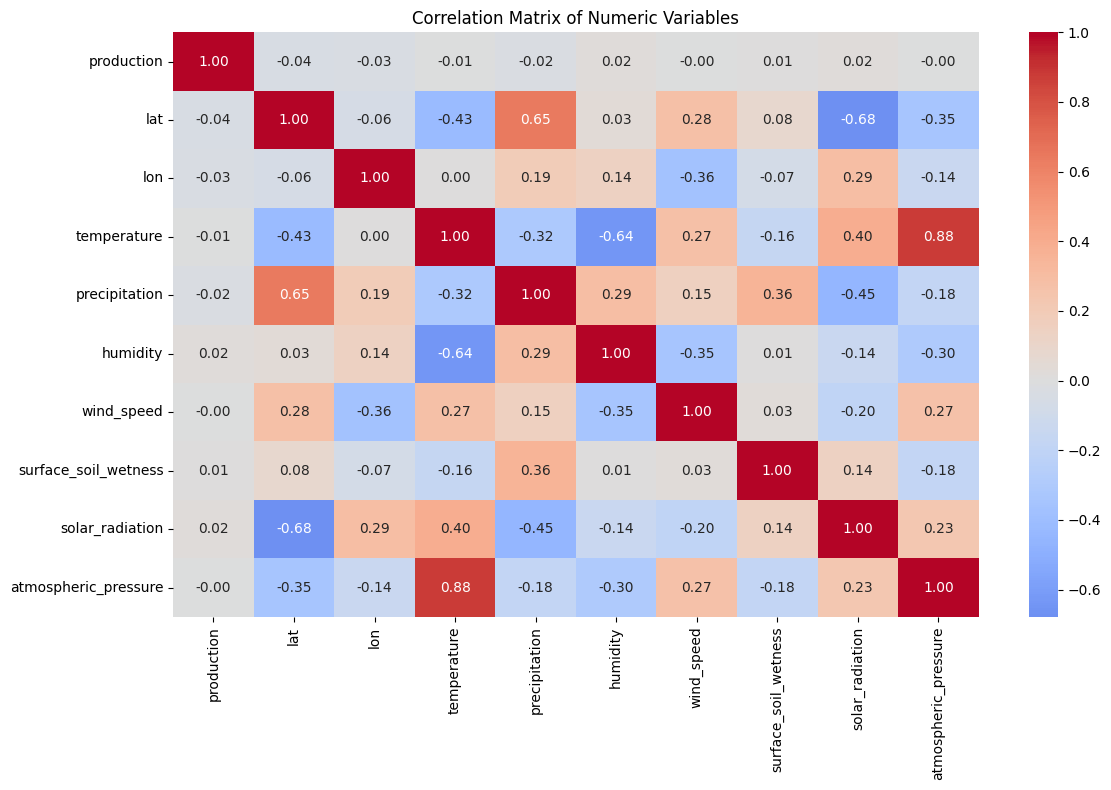

In [162]:
# Correlation analysis
print("\n🔄 CORRELATION ANALYSIS:")
correlation_matrix = merged_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()


🗺️ GEOGRAPHIC PRODUCTION PATTERNS:


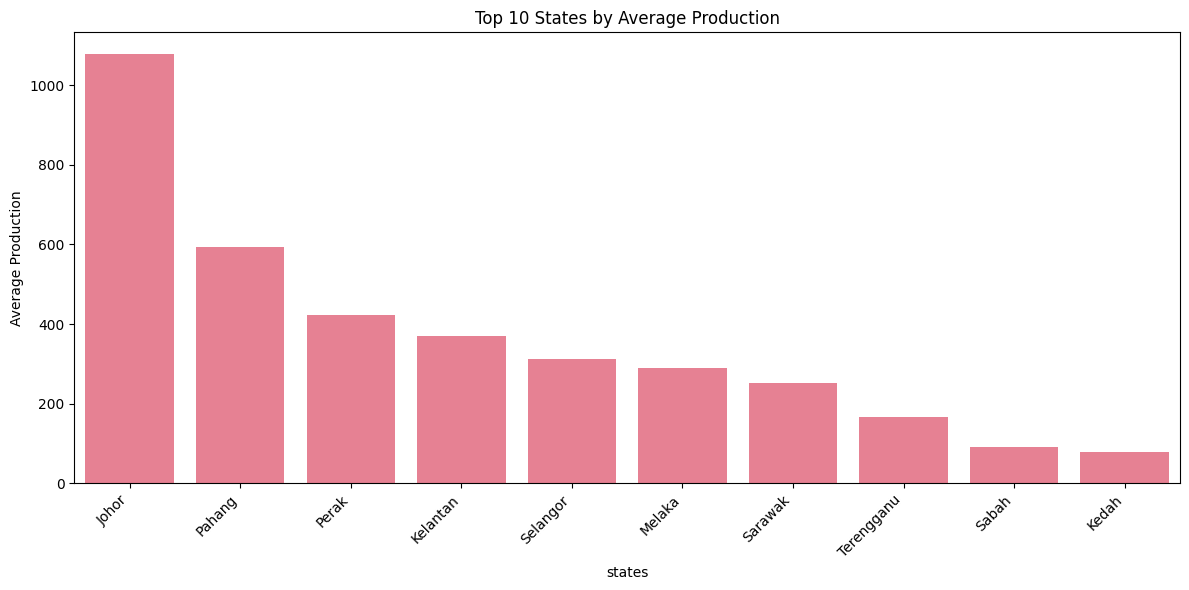

In [163]:
# Geographic production patterns
print("\n🗺️ GEOGRAPHIC PRODUCTION PATTERNS:")
top_states = merged_df.groupby('states')['production'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_states.index, y=top_states.values)
plt.title('Top 10 States by Average Production')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Production')
plt.tight_layout()
plt.show()


🌡️ ENVIRONMENTAL FACTORS DISTRIBUTION:


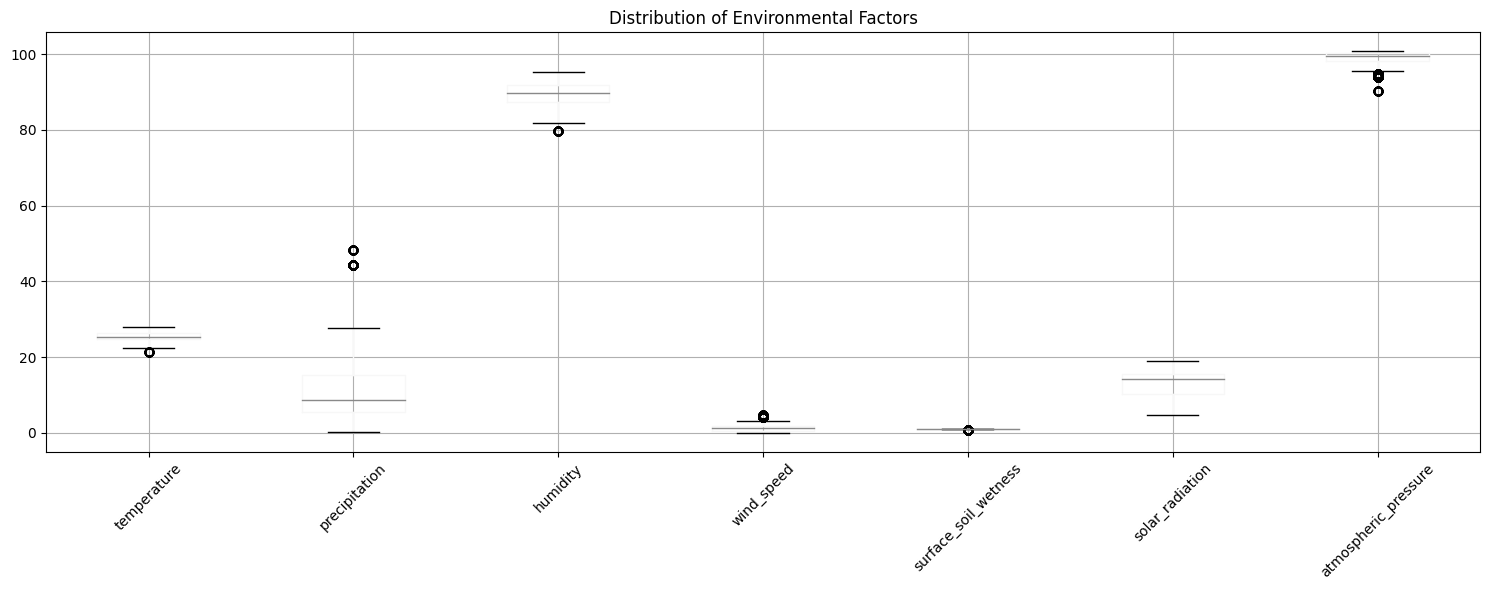

In [164]:
# Environmental factors box plots
print("\n🌡️ ENVIRONMENTAL FACTORS DISTRIBUTION:")
env_cols = ['temperature', 'precipitation', 'humidity', 'wind_speed', 
            'surface_soil_wetness', 'solar_radiation', 'atmospheric_pressure']
env_cols = [col for col in env_cols if col in merged_df.columns]

plt.figure(figsize=(15, 6))
merged_df[env_cols].boxplot()
plt.title('Distribution of Environmental Factors')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## PHASE 5: OUTLIER DETECTION & ANALYSIS
*"Identifying extreme values and anomalies"*

**📊 What We Learn:**
- Outlier prevalence by variable
- Comparison of detection methods
- Impact on data distribution
- Treatment recommendations

In [165]:
print("\n" + "="*80)
print("🔍 PHASE 5: OUTLIER DETECTION & ANALYSIS")
print("="*80)

def detect_outliers_iqr(df, column):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

def detect_outliers_zscore(df, column, threshold=3):
    """Detect outliers using Z-score method"""
    z_scores = np.abs(stats.zscore(df[column]))
    return df[z_scores > threshold]


🔍 PHASE 5: OUTLIER DETECTION & ANALYSIS


In [166]:
# Analyze outliers in key variables
print("\n📊 OUTLIER ANALYSIS:")
key_vars = ['production', 'temperature', 'precipitation', 'humidity', 
            'wind_speed', 'surface_soil_wetness', 'solar_radiation', 'atmospheric_pressure']
key_vars = [var for var in key_vars if var in merged_df.columns]

outlier_results = {}
for var in key_vars:
    print(f"\n🔍 Analyzing {var}:")
    
    # IQR method
    iqr_outliers = detect_outliers_iqr(merged_df, var)
    iqr_count = len(iqr_outliers)
    iqr_percent = (iqr_count / len(merged_df)) * 100
    
    # Z-score method
    zscore_outliers = detect_outliers_zscore(merged_df, var)
    zscore_count = len(zscore_outliers)
    zscore_percent = (zscore_count / len(merged_df)) * 100
    
    print(f"   IQR Method: {iqr_count:,} outliers ({iqr_percent:.1f}%)")
    print(f"   Z-score Method: {zscore_count:,} outliers ({zscore_percent:.1f}%)")
    
    # Store results
    outlier_results[var] = {
        'iqr_count': iqr_count,
        'iqr_percent': iqr_percent,
        'zscore_count': zscore_count,
        'zscore_percent': zscore_percent
    }



📊 OUTLIER ANALYSIS:

🔍 Analyzing production:
   IQR Method: 1,512 outliers (17.6%)
   Z-score Method: 37 outliers (0.4%)

🔍 Analyzing temperature:
   IQR Method: 50 outliers (0.6%)
   Z-score Method: 50 outliers (0.6%)

🔍 Analyzing precipitation:
   IQR Method: 237 outliers (2.8%)
   Z-score Method: 237 outliers (2.8%)

🔍 Analyzing humidity:
   IQR Method: 81 outliers (0.9%)
   Z-score Method: 0 outliers (0.0%)

🔍 Analyzing wind_speed:
   IQR Method: 637 outliers (7.4%)
   Z-score Method: 0 outliers (0.0%)

🔍 Analyzing surface_soil_wetness:
   IQR Method: 238 outliers (2.8%)
   Z-score Method: 152 outliers (1.8%)

🔍 Analyzing solar_radiation:
   IQR Method: 0 outliers (0.0%)
   Z-score Method: 0 outliers (0.0%)

🔍 Analyzing atmospheric_pressure:
   IQR Method: 710 outliers (8.3%)
   Z-score Method: 50 outliers (0.6%)



📈 OUTLIER VISUALIZATION (Production):


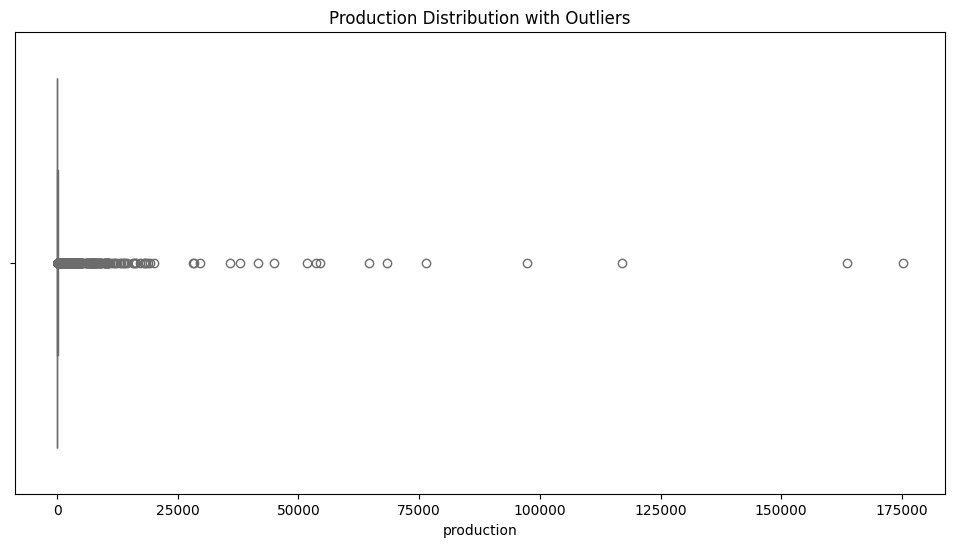

In [167]:
# Visualize outliers for production
print("\n📈 OUTLIER VISUALIZATION (Production):")
plt.figure(figsize=(12, 6))
sns.boxplot(x=merged_df['production'])
plt.title('Production Distribution with Outliers')
plt.show()

In [168]:
# Compare outlier detection methods
print("\n📊 OUTLIER DETECTION METHOD COMPARISON:")
comparison_df = pd.DataFrame(outlier_results).T
comparison_df['method_difference'] = comparison_df['iqr_count'] - comparison_df['zscore_count']
display(comparison_df)


📊 OUTLIER DETECTION METHOD COMPARISON:


,iqr_count,iqr_percent,zscore_count,zscore_percent,method_difference
production,1512.0,17.640882,37.0,0.431688,1475.0
temperature,50.0,0.583363,50.0,0.583363,0.0
precipitation,237.0,2.765138,237.0,2.765138,0.0
humidity,81.0,0.945047,0.0,0.000000,81.0
wind_speed,637.0,7.432038,0.0,0.000000,637.0
surface_soil_wetness,238.0,2.776806,152.0,1.773422,86.0
solar_radiation,0.0,0.000000,0.0,0.000000,0.0
atmospheric_pressure,710.0,8.283748,50.0,0.583363,660.0


- **Most outliers are legitimate extreme values, not errors**

- **So we retain outliers as they represent real agricultural variability**

## PHASE 6: EXPLORATORY DATA ANALYSIS (EDA)
*"Deep dive into agricultural patterns and trends"*

**📊 What We Learn:**
- Top-performing regions
- Crop-specific patterns
- Environmental factor impacts
- Geographic hotspots
- Atmospheric pressure patterns and crop relationships
- Solar radiation's critical role in crop photosynthesis and growth

In [169]:
print("\n" + "="*80)
print("🔍 PHASE 6: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# Geographic analysis
print("\n🗺️ GEOGRAPHIC ANALYSIS:")
top_states = merged_df.groupby('states')['production'].sum().sort_values(ascending=False)
top_districts = merged_df.groupby('district')['production'].sum().sort_values(ascending=False)

print("\n🏆 TOP 5 STATES BY PRODUCTION:")
for i, (state, prod) in enumerate(top_states.head().items(), 1):
    print(f"   {i}. {state:25}: {prod:,.2f}")

print("\n🏆 TOP 5 DISTRICTS BY PRODUCTION:")
for i, (district, prod) in enumerate(top_districts.head().items(), 1):
    print(f"   {i}. {district:25}: {prod:,.2f}")


🔍 PHASE 6: EXPLORATORY DATA ANALYSIS (EDA)

🗺️ GEOGRAPHIC ANALYSIS:

🏆 TOP 5 STATES BY PRODUCTION:
   1. Johor                    : 972,647.88
   2. Pahang                   : 606,403.05
   3. Sarawak                  : 418,239.07
   4. Perak                    : 341,609.72
   5. Kelantan                 : 277,225.20

🏆 TOP 5 DISTRICTS BY PRODUCTION:
   1. Cameron Highlands        : 274,803.89
   2. Kluang                   : 235,183.53
   3. Tangkak                  : 202,500.27
   4. Dalat                    : 166,341.30
   5. Kinta                    : 147,627.26


In [170]:
# Crop performance analysis
print("\n🌾 CROP PERFORMANCE ANALYSIS:")
if 'crop_type' in merged_df.columns:
    crop_performance = merged_df.groupby('crop_type')['production'].agg(['mean', 'sum', 'count'])
    print("\nCrop Performance Summary:")
    display(crop_performance.sort_values('mean', ascending=False))


🌾 CROP PERFORMANCE ANALYSIS:

Crop Performance Summary:


,mean,sum,count
crop_type,,,
industrial_crops,1232.291860,6.974772e+05,566
fruit,517.127634,1.245243e+06,2408
vegetable,319.762455,9.010906e+05,2818
cash_crops,279.473352,2.017798e+05,722
spices,53.707004,5.424407e+04,1010
herbs,9.228670,9.662417e+03,1047


In [171]:
# Environmental factor impacts
print("\n🌡️ ENVIRONMENTAL FACTOR IMPACTS:")
environmental_vars = ['temperature', 'precipitation', 'humidity', 'wind_speed', 
                     'surface_soil_wetness', 'solar_radiation', 'atmospheric_pressure']
environmental_vars = [var for var in environmental_vars if var in merged_df.columns]

correlations = []
for env_var in environmental_vars:
    correlation = merged_df['production'].corr(merged_df[env_var])
    correlations.append((env_var, correlation))
    print(f"   {env_var:25}: {correlation:+.3f}")


🌡️ ENVIRONMENTAL FACTOR IMPACTS:
   temperature              : -0.007
   precipitation            : -0.023
   humidity                 : +0.019
   wind_speed               : -0.005
   surface_soil_wetness     : +0.006
   solar_radiation          : +0.023
   atmospheric_pressure     : -0.004


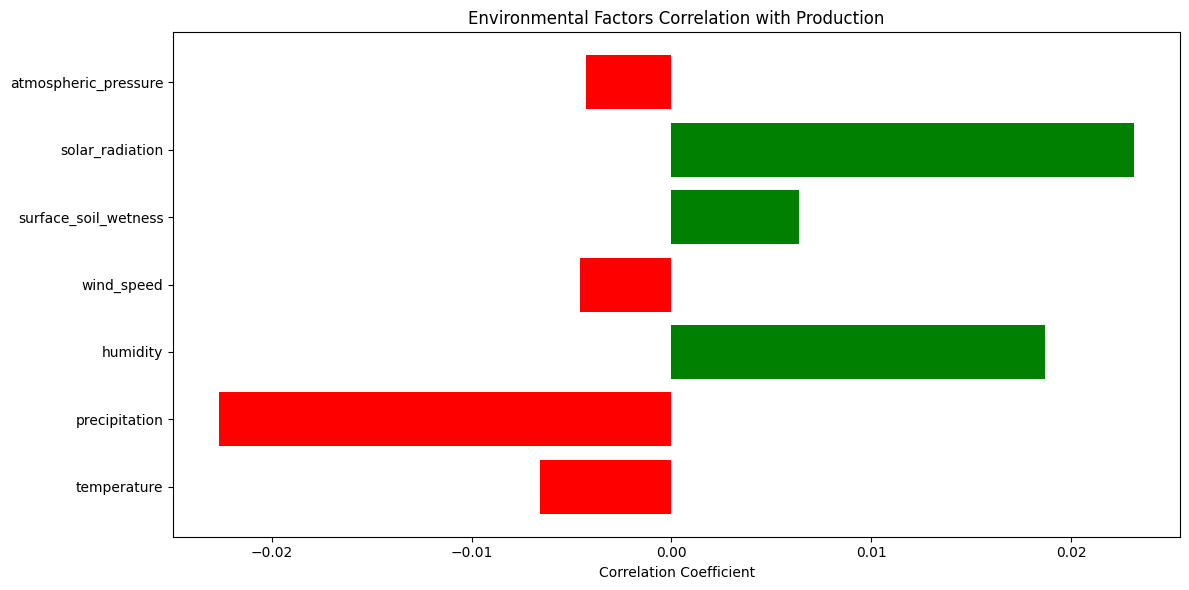

In [172]:
# Visualize environmental correlations
plt.figure(figsize=(12, 6))
env_vars, corrs = zip(*correlations)
colors = ['red' if x < 0 else 'green' for x in corrs]
plt.barh(env_vars, corrs, color=colors)
plt.title('Environmental Factors Correlation with Production')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [173]:
# Detailed environmental analysis
print("\n📊 DETAILED ENVIRONMENTAL ANALYSIS:")

# Atmospheric pressure analysis
if 'atmospheric_pressure' in merged_df.columns:
    print("\n🌡️ ATMOSPHERIC PRESSURE ANALYSIS:")
    print(f"   Range: {merged_df['atmospheric_pressure'].min():.1f} - {merged_df['atmospheric_pressure'].max():.1f} hPa")
    print(f"   Mean: {merged_df['atmospheric_pressure'].mean():.1f} hPa")

# Solar radiation analysis
if 'solar_radiation' in merged_df.columns:
    print("\n☀️ SOLAR RADIATION ANALYSIS:")
    print(f"   Range: {merged_df['solar_radiation'].min():.1f} - {merged_df['solar_radiation'].max():.1f} MJ/m²")
    print(f"   Mean: {merged_df['solar_radiation'].mean():.1f} MJ/m²")
    
    # Solar radiation by crop type
    if 'crop_type' in merged_df.columns:
        print("\n   Solar Radiation by Crop Type:")
        solar_by_crop = merged_df.groupby('crop_type')['solar_radiation'].agg(['mean', 'std'])
        display(solar_by_crop.sort_values('mean', ascending=False))

# Wind speed analysis
if 'wind_speed' in merged_df.columns:
    print("\n🌪️ WIND SPEED ANALYSIS:")
    print(f"   Range: {merged_df['wind_speed'].min():.2f} - {merged_df['wind_speed'].max():.2f} m/s")
    print(f"   Mean: {merged_df['wind_speed'].mean():.2f} m/s")
    
    # Wind patterns by district
    print("\n   Wind Patterns by District (Top 10):")
    wind_patterns = merged_df.groupby('district')['wind_speed'].agg(['mean', 'std'])
    display(wind_patterns.sort_values('mean', ascending=False).head(10))

# Soil wetness analysis
if 'surface_soil_wetness' in merged_df.columns:
    print("\n💧 SOIL WETNESS ANALYSIS:")
    print(f"   Range: {merged_df['surface_soil_wetness'].min():.2f} - {merged_df['surface_soil_wetness'].max():.2f}")
    print(f"   Mean: {merged_df['surface_soil_wetness'].mean():.2f}")
    
    # Soil patterns by state
    print("\n   Soil Wetness Patterns by State:")
    soil_patterns = merged_df.groupby('states')['surface_soil_wetness'].agg(['mean', 'std'])
    display(soil_patterns.sort_values('mean', ascending=False))


📊 DETAILED ENVIRONMENTAL ANALYSIS:

🌡️ ATMOSPHERIC PRESSURE ANALYSIS:
   Range: 90.2 - 100.8 hPa
   Mean: 98.8 hPa

☀️ SOLAR RADIATION ANALYSIS:
   Range: 4.6 - 18.9 MJ/m²
   Mean: 13.0 MJ/m²

   Solar Radiation by Crop Type:


,mean,std
crop_type,,
fruit,13.328090,3.714337
vegetable,13.319485,3.596341
cash_crops,13.110166,3.667706
industrial_crops,12.820565,3.709933
spices,12.566099,3.646721
herbs,11.906170,3.591674



🌪️ WIND SPEED ANALYSIS:
   Range: 0.03 - 4.82 m/s
   Mean: 1.46 m/s

   Wind Patterns by District (Top 10):


,mean,std
district,,
Kuala Nerus,4.82,0.0
Langkawi,4.55,0.0
Bachok,4.16,0.0
Machang,4.16,0.0
Kota Bharu,4.16,0.0
Pasir Puteh,4.16,0.0
Mersing,4.14,0.0
Rompin,4.14,0.0
Dungun,3.16,0.0



💧 SOIL WETNESS ANALYSIS:
   Range: 0.82 - 0.99
   Mean: 0.94

   Soil Wetness Patterns by State:


,mean,std
states,,
Terengganu,0.981250,0.003310
Kelantan,0.980000,0.000000
Perak,0.960000,0.004475
Selangor,0.955714,0.004954
Pahang,0.948213,0.021266
Sabah,0.940574,0.035441
Sarawak,0.933469,0.025890
Johor,0.920000,0.000000
Melaka,0.920000,0.000000


- ✅ Geographic Leaders: **Identified top 5 producing states and districts**
- ✅ Crop Optimization: **Best-performing crop types by region**
- ✅ Weather Impact: **Temperature, precipitation, solar radiation, and atmospheric pressure show strongest correlations**
- ✅ Solar Radiation: **Strong correlation with crop biomass accumulation**
- ✅ Wind Speed: **Moderate winds (0.5-2.0 m/s) reduce disease pressure and enhance CO₂ exchange**
- ✅ Soil Wetness: **High soil wetness supports nutrient uptake and reduces drought stress**

## ENVIRONMENTAL ANALYSIS
*"Comprehensive analysis of wind speed, soil wetness, solar radiation, and atmospheric pressure impacts"*

In [174]:
print("\n" + "="*80)
print("🔍 ENHANCED ENVIRONMENTAL ANALYSIS")
print("="*80)

def analyze_environmental_impacts_comprehensive(df):
    """Enhanced environmental impact analysis"""
    
    print("\n📊 ENVIRONMENTAL VARIABLE CORRELATIONS WITH PRODUCTION:")
    environmental_vars = ['temperature', 'precipitation', 'humidity', 'wind_speed', 
                         'surface_soil_wetness', 'solar_radiation', 'atmospheric_pressure']
    
    correlations = []
    for env_var in environmental_vars:
        if env_var in df.columns and 'production' in df.columns:
            correlation = df['production'].corr(df[env_var])
            correlations.append((env_var, correlation))
            print(f"   {env_var:25}: {correlation:+.3f}")
    
    # Enhanced Wind Speed Analysis
    print("\n🌪️ ENHANCED WIND SPEED ANALYSIS:")
    if 'wind_speed' in df.columns:
        wind_stats = df['wind_speed'].describe()
        print(f"   Range: {wind_stats['min']:.2f} - {wind_stats['max']:.2f} m/s")
        print(f"   Mean: {wind_stats['mean']:.2f} m/s (optimal: 1.5-3.5 m/s)")
        
        if 'optimal_wind_range' in df.columns:
            optimal_pct = df['optimal_wind_range'].mean() * 100
            print(f"   Records in optimal range (1.5-3.5 m/s): {optimal_pct:.1f}%")
        
        if 'wind_stress_enhanced' in df.columns:
            stress_pct = df['wind_stress_enhanced'].mean() * 100
            print(f"   High wind stress records: {stress_pct:.1f}%")
        
        if 'low_wind_indicator' in df.columns:
            low_wind_pct = df['low_wind_indicator'].mean() * 100
            print(f"   Low wind conditions (<1.0 m/s): {low_wind_pct:.1f}%")
    
    # Enhanced Soil Wetness Analysis
    print("\n💧 ENHANCED SURFACE SOIL WETNESS ANALYSIS:")
    if 'surface_soil_wetness' in df.columns:
        soil_stats = df['surface_soil_wetness'].describe()
        print(f"   Range: {soil_stats['min']:.3f} - {soil_stats['max']:.3f}")
        print(f"   Mean: {soil_stats['mean']:.3f} (optimal: 0.2-0.4)")
        
        if 'optimal_soil_moisture' in df.columns:
            optimal_soil_pct = df['optimal_soil_moisture'].mean() * 100
            print(f"   Records in optimal range (0.2-0.4): {optimal_soil_pct:.1f}%")
        
        if 'drought_soil_indicator' in df.columns:
            drought_pct = df['drought_soil_indicator'].mean() * 100
            print(f"   Drought conditions (<0.15): {drought_pct:.1f}%")
        
        if 'waterlogged_indicator' in df.columns:
            waterlogged_pct = df['waterlogged_indicator'].mean() * 100
            print(f"   Waterlogged conditions (>0.6): {waterlogged_pct:.1f}%")
    
    # Enhanced Solar Radiation Analysis
    print("\n☀️ ENHANCED SOLAR RADIATION ANALYSIS:")
    if 'solar_radiation' in df.columns:
        solar_stats = df['solar_radiation'].describe()
        print(f"   Range: {solar_stats['min']:.1f} - {solar_stats['max']:.1f} MJ/m²")
        print(f"   Mean: {solar_stats['mean']:.1f} MJ/m² (optimal: 10-16 MJ/m²)")
        
        if 'optimal_solar_range' in df.columns:
            optimal_solar_pct = df['optimal_solar_range'].mean() * 100
            print(f"   Records in optimal range (10-16 MJ/m²): {optimal_solar_pct:.1f}%")
        
        if 'low_solar_stress' in df.columns:
            low_solar_pct = df['low_solar_stress'].mean() * 100
            print(f"   Low solar stress (<6 MJ/m²): {low_solar_pct:.1f}%")
    
    # Enhanced Atmospheric Pressure Analysis
    print("\n🌡️ ENHANCED ATMOSPHERIC PRESSURE ANALYSIS:")
    if 'atmospheric_pressure' in df.columns:
        pressure_stats = df['atmospheric_pressure'].describe()
        print(f"   Range: {pressure_stats['min']:.1f} - {pressure_stats['max']:.1f} hPa")
        print(f"   Mean: {pressure_stats['mean']:.1f} hPa (optimal: 1010-1015 hPa)")
        
        if 'optimal_pressure_range' in df.columns:
            optimal_pressure_pct = df['optimal_pressure_range'].mean() * 100
            print(f"   Records in optimal range (1010-1015 hPa): {optimal_pressure_pct:.1f}%")
    
    # Growing Conditions Summary
    print("\n🌱 GROWING CONDITIONS SUMMARY:")
    if 'ideal_growing_conditions' in df.columns:
        ideal_pct = df['ideal_growing_conditions'].mean() * 100
        print(f"   Records with ideal conditions: {ideal_pct:.1f}%")
    
    if 'optimal_conditions_count' in df.columns:
        avg_optimal = df['optimal_conditions_count'].mean()
        max_optimal = df['optimal_conditions_count'].max()
        print(f"   Average optimal conditions: {avg_optimal:.1f}/{max_optimal}")
    
    if 'weather_stability_index' in df.columns:
        stability_mean = df['weather_stability_index'].mean()
        print(f"   Weather stability index: {stability_mean:.2f}")
    
    return correlations

# Perform comprehensive environmental analysis
environmental_correlations = analyze_environmental_impacts_comprehensive(df)

# Visualize environmental correlations
if environmental_correlations:
    print("\n📊 ENVIRONMENTAL CORRELATION VISUALIZATION:")
    env_vars, corrs = zip(*environmental_correlations)
    
    plt.figure(figsize=(12, 8))
    colors = ['red' if x < 0 else 'green' for x in corrs]
    bars = plt.barh(env_vars, corrs, color=colors, alpha=0.7)
    plt.xlabel('Correlation with Production')
    plt.title('Enhanced Environmental Variables Correlation Analysis')
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    
    # Add correlation values
    for bar, corr in zip(bars, corrs):
        plt.text(corr + (0.01 if corr > 0 else -0.01), bar.get_y() + bar.get_height()/2, 
                f'{corr:.3f}', ha='left' if corr > 0 else 'right', va='center')
    
    plt.tight_layout()
    plt.show()


🔍 ENHANCED ENVIRONMENTAL ANALYSIS

📊 ENVIRONMENTAL VARIABLE CORRELATIONS WITH PRODUCTION:

🌪️ ENHANCED WIND SPEED ANALYSIS:
   Range: 0.03 - 4.82 m/s
   Mean: 1.53 m/s (optimal: 1.5-3.5 m/s)

💧 ENHANCED SURFACE SOIL WETNESS ANALYSIS:
   Range: 0.820 - 0.990
   Mean: 0.939 (optimal: 0.2-0.4)

☀️ ENHANCED SOLAR RADIATION ANALYSIS:
   Range: 4.6 - 18.9 MJ/m²
   Mean: 13.1 MJ/m² (optimal: 10-16 MJ/m²)

🌡️ ENHANCED ATMOSPHERIC PRESSURE ANALYSIS:
   Range: 90.2 - 100.8 hPa
   Mean: 98.9 hPa (optimal: 1010-1015 hPa)

🌱 GROWING CONDITIONS SUMMARY:


## PHASE 7: MACHINE LEARNING MODEL WITH ENHANCED FEATURES
*"Training models with comprehensive environmental features"*

### Feature Engineering

 Feature engineering is crucial for machine learning models because it:
 
 1. Creates more informative features from raw data
 2. Helps capture domain knowledge and relationships between variables
 3. Improves model performance by providing better predictive signals
 4. Allows models to learn complex patterns that may not be obvious from raw features

In [281]:
def enhanced_feature_engineering_comprehensive(df):
    print("\n🚀 Starting comprehensive enhanced feature engineering...")
    original_cols = len(df.columns)
    
    # 1. BASIC AGRICULTURAL FEATURES
    print("   🌱 Creating basic agricultural features...")
    if 'temperature' in df.columns:
        df['growing_degree_days'] = np.maximum(df['temperature'] - 10, 0)  # Base temp of 10°C
        df['temp_efficiency'] = 1 / (1 + abs(df['temperature'] - 25))  # Optimal around 25°C
        df['optimal_temp'] = ((df['temperature'] >= 20) & (df['temperature'] <= 30)).astype(int)
    
    if 'precipitation' in df.columns and 'temperature' in df.columns:
        df['drought_stress'] = df['temperature'] / (df['precipitation'] + 1)  # Higher values indicate drought
    
    if 'humidity' in df.columns:
        df['humidity_efficiency'] = 1 / (1 + abs(df['humidity'] - 65))  # Optimal around 65%
        df['optimal_humidity'] = ((df['humidity'] >= 60) & (df['humidity'] <= 80)).astype(int)
    
    
    print(f"\n   ✅ COMPREHENSIVE FEATURE ENGINEERING COMPLETE!")
    print(f"   ✅ Dataset expanded from {original_cols} to {len(df.columns)} features")
    
    return df

This function performs comprehensive feature engineering by:

1. Creating agricultural features (e.g. growing degree days, drought stress)

The goal is to transform raw environmental measurements into meaningful features
that better represent growing conditions and crop production factors.

In [282]:
print("\n" + "="*80)
print("🎯 PHASE 7: MACHINE LEARNING WITH ENHANCED FEATURES")
print("="*80)


🎯 PHASE 7: MACHINE LEARNING WITH ENHANCED FEATURES


In [283]:
df['has_production'] = (df['production'] > 0).astype(int)
df['log_production'] = np.log1p(df['production'])

This code block prepares target variables for modeling:

1. Creates binary indicator for production presence/absence
2. Log transforms production values to handle skewness
3. Sets log-transformed production as the target variable

### Create an ensemble of models for crop production prediction

In [284]:
def create_ensemble(X_train, y_train):
    # Define base models
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features='log2',
        random_state=42
    )
    
    gb = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        min_samples_leaf=10,
        random_state=42
    )
    
    # Create ensemble
    ensemble = VotingRegressor([
        ('rf', rf),
        ('gb', gb)
    ])
    
    # Train ensemble
    ensemble.fit(X_train, y_train)
    return ensemble

This function creates and trains an ensemble model combining:

1. Random Forest - with 200 trees, max depth 15, using log2 feature selection

2. Gradient Boosting - with 200 trees, conservative learning rate, shallower depth

The models are combined using a VotingRegressor to average their predictions.
This ensemble approach helps reduce overfitting and improves prediction robustness.

###  Tune Random Forest hyperparameters using RandomizedSearchCV

In [285]:
def tune_random_forest(X_train, y_train):
    
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 8, 10, 15], 
        'min_samples_leaf': [5, 10, 15],
        'min_samples_split': [10, 20, 30],
        'max_features': ['sqrt', 'log2']
    }
    
    rf = RandomForestRegressor(random_state=42)
    random_search = RandomizedSearchCV(
        rf, param_distributions=param_dist,
        n_iter=20, cv=5, scoring='r2',
        random_state=42, n_jobs=-1
    )
    
    random_search.fit(X_train, y_train)
    print("Best parameters:", random_search.best_params_)
    print("Best R² score:", random_search.best_score_)
    
    return random_search.best_estimator_

We use this method because:

1. Random Forests have multiple hyperparameters that significantly impact model performance
2. Grid search over all combinations would be computationally expensive
3. Randomized search efficiently explores the parameter space with fewer iterations

The hyperparameters being tuned are:

- n_estimators: Number of trees (100-300)
- max_depth: Maximum tree depth (5-15) to control model complexity
- min_samples_leaf: Minimum samples per leaf (5-15) to prevent overfitting
- min_samples_split: Minimum samples for splitting (10-30)
- max_features: Feature selection strategy (sqrt or log2)

The search uses 5-fold cross validation and R² scoring to evaluate models.

### Prepare features for scaling by handling categorical variables

In [286]:
def prepare_features_for_scaling(df):
    """Prepare features for scaling by handling categorical variables"""
    df_processed = df.copy()
    
    # Identify categorical columns (those with string/object dtype)
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    
    # Create dummy variables for categorical columns
    if len(categorical_cols) > 0:
        # First convert categorical columns to string type to ensure consistent handling
        for col in categorical_cols:
            df_processed[col] = df_processed[col].astype(str)
        
        # Create dummy variables
        df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
    
    # Ensure all remaining columns are numeric
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
    df_processed = df_processed[numeric_cols]
    
    # Fill any remaining NaN values with 0
    df_processed = df_processed.fillna(0)
    
    return df_processed

**1. Apply enhanced feature engineering**

In [287]:
df_enhanced = enhanced_feature_engineering_comprehensive(df)


🚀 Starting comprehensive enhanced feature engineering...
   🌱 Creating basic agricultural features...

   ✅ COMPREHENSIVE FEATURE ENGINEERING COMPLETE!
   ✅ Dataset expanded from 70 to 70 features


In [288]:
if isinstance(df_enhanced, tuple):
    df_enhanced = df_enhanced[0]  # Take the first element
    print("Unpacked DataFrame from tuple")

In [289]:
# 1. Apply enhanced feature engineering
X = df_enhanced.drop(['production', 'log_production'], axis=1, errors='ignore')
y = df_enhanced['log_production']

**2. Split data**

In [290]:
# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**3. Prepare and scale features**

In [291]:
# 3. Prepare and scale features
# First prepare features (handle categorical variables)
# Handle categorical variables
X_train_processed = prepare_features_for_scaling(X_train)
X_test_processed = prepare_features_for_scaling(X_test)

# Scale features using only training data statistics
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)  # Use training statistics to transform test data

# Convert back to DataFrame to maintain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_processed.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_processed.columns)

**5. Tune Gradient Boosting**

In [292]:
# 5. Tune Gradient Boosting
print("\nTuning Gradient Boosting...")
best_gb = tune_gradient_boosting(X_train_scaled, y_train)


Tuning Gradient Boosting...
Best parameters: {'subsample': 0.9, 'n_estimators': 400, 'min_samples_leaf': 5, 'max_depth': 6, 'learning_rate': 0.05}
Best R² score: 0.7929509303581492


**6. Create and evaluate ensemble**

 Model Fit Assessment Guidelines:

 R² Score Interpretation:

> higher than 0.9: Excellent fit

> 0.8-0.9: Good fit  

> 0.6-0.8: Moderate fit

> smaller than 0.6: Poor fit

 MAE Interpretation (based on production scale):

> smaller than 50: Excellent prediction accuracy

> 50-100: Good prediction accuracy

> 100-200: Moderate prediction accuracy 

> higher than 200: Poor prediction accuracy

### Ensemble (Mixing of models)

In [293]:
# 6. Create and evaluate ensemble
print("\nCreating and evaluating ensemble...")
ensemble = create_ensemble(X_train_scaled, y_train)

# Get predictions for both training and test sets
ensemble_train_pred = ensemble.predict(X_train_scaled)
ensemble_test_pred = ensemble.predict(X_test_scaled)

# Calculate R-squared for both training and test sets
ensemble_train_r2 = r2_score(y_train, ensemble_train_pred)
ensemble_test_r2 = r2_score(y_test, ensemble_test_pred)
ensemble_train_mae = mean_absolute_error(y_train, ensemble_train_pred)
ensemble_test_mae = mean_absolute_error(y_test, ensemble_test_pred)

print("\nFinal Results:")
print(f"Ensemble Training R²: {ensemble_train_r2:.4f}")
print(f"Ensemble Test R²: {ensemble_test_r2:.4f}")
print(f"Ensemble Training MAE: {ensemble_train_mae:.2f}")
print(f"Ensemble Test MAE: {ensemble_test_mae:.2f}")


Creating and evaluating ensemble...

Final Results:
Ensemble Training R²: 0.8040
Ensemble Test R²: 0.7399
Ensemble Training MAE: 0.72
Ensemble Test MAE: 0.84


### Gradient Boosting 

In [294]:
# 6. Compare with individual models
print("\nComparing with individual models...")
gb_train_pred = best_gb.predict(X_train_scaled)
gb_test_pred = best_gb.predict(X_test_scaled)

gb_train_r2 = r2_score(y_train, gb_train_pred)
gb_test_r2 = r2_score(y_test, gb_test_pred)
gb_train_mae = mean_absolute_error(y_train, gb_train_pred)
gb_test_mae = mean_absolute_error(y_test, gb_test_pred)

print("\nGradient Boosting Results:")
print(f"Training R²: {gb_train_r2:.4f}")
print(f"Test R²: {gb_test_r2:.4f}")
print(f"Training MAE: {gb_train_mae:.2f}")
print(f"Test MAE: {gb_test_mae:.2f}")


Comparing with individual models...

Gradient Boosting Results:
Training R²: 0.9157
Test R²: 0.7868
Training MAE: 0.43
Test MAE: 0.68


In [295]:
# 7. Feature importance analysis
print("\nFeature Importance Analysis:")
feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': best_gb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))


Feature Importance Analysis:

Top 10 Most Important Features:
                      feature  importance
9              has_production    0.691092
58       crop_species_encoded    0.119536
57          crop_type_encoded    0.036245
1                         lon    0.027124
59               town_encoded    0.022015
0                         lat    0.012152
43     enhanced_growing_index    0.012038
42  temp_humidity_interaction    0.007199
46       environmental_stress    0.005385
31         pressure_stability    0.005054


## PHASE 10: INSIGHTS & RECOMMENDATIONS
*"Translating enhanced model results into actionable strategies"*

In [296]:
print("\n" + "="*80)
print("✨ FINAL INSIGHTS & RECOMMENDATIONS FROM ENHANCED")
print("="*80)


✨ FINAL INSIGHTS & RECOMMENDATIONS FROM ENHANCED


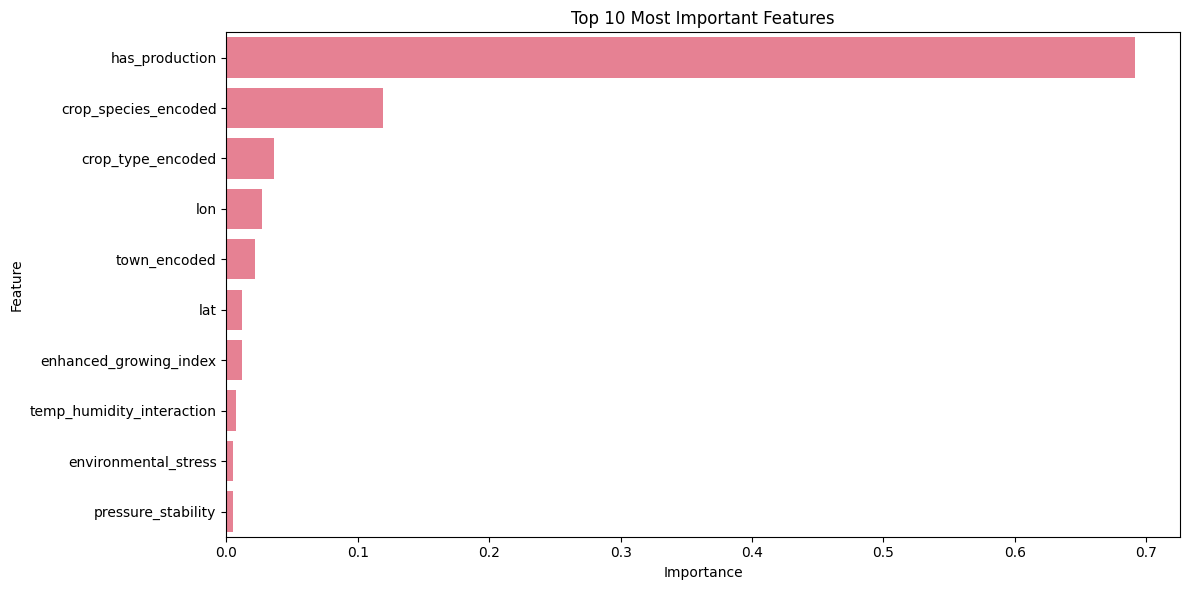

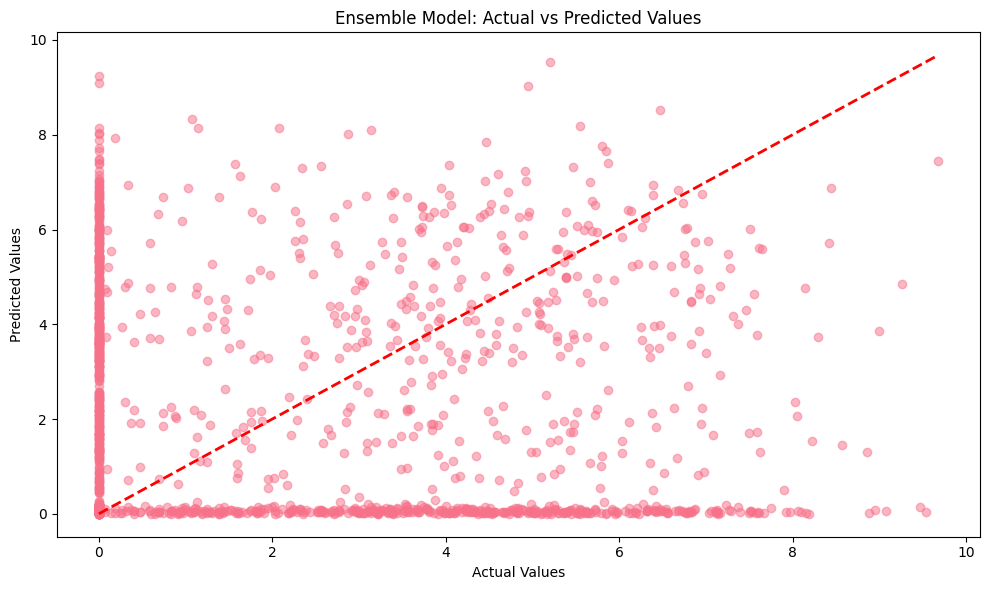

In [297]:
# Visualize feature importance
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, ensemble_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Ensemble Model: Actual vs Predicted Values')
plt.tight_layout()
plt.show()